# Data Prep

In [1]:
import zipfile
from pathlib import Path
import rasterio
from rasterio.merge import merge
from rasterio.warp import transform_bounds
from rasterio.mask import mask
from rasterio.warp import calculate_default_transform, reproject, Resampling
from rasterio.env import Env


import shutil
import subprocess
import tempfile
import geopandas as gpd
import rioxarray as rxr
import xarray as xr


# Base path for all data
base_path = Path("/home/georg/data/LEON_P5_BII")

# Merging (zip)filed tifs

## Merging all .tif files within ZIP

In [1]:
def process_eo_dataset(base_path, dataset, folder, country, year):
    """
    Unzips all .zip files for a given dataset/country/year,
    extracts all .tif files, mosaics them and saves a single output .tif.
    """

    # Build paths
    input_dir = base_path / "EO_data_raw" / folder / f"{dataset}_{country}_{year}"
    output_dir = base_path / "EO_data_prep" / folder
    output_dir.mkdir(parents=True, exist_ok=True)

    print(f"\n=== Processing {dataset} | {country.upper()} | {year} ===")
    print(f"Input directory: {input_dir}")

    if not input_dir.exists():
        print("❌ Directory does not exist — skipping.")
        return

    # Find ZIP files
    zip_files = list(input_dir.glob("*.zip"))
    print(f"Found {len(zip_files)} zip files")

    if not zip_files:
        print("❌ No zip files found — skipping.")
        return

    # Temporary dir for extracted tif
    temp_dir = Path("temp_eo_extract")
    temp_dir.mkdir(exist_ok=True)

    tif_files = []

    # Extract TIFFS
    for zf in zip_files:
        print(f"Processing ZIP: {zf.name}")
        with zipfile.ZipFile(zf) as z:
            tif_matches = [n for n in z.namelist() if n.endswith(".tif")]

            if not tif_matches:
                print(f"  ⚠️ No .tif files in {zf.name}")
                continue

            # Extract first TIFF
            tif_name = tif_matches[0]
            z.extract(tif_name, temp_dir)
            tif_files.append(temp_dir / tif_name)

    print(f"Total extracted TIFFs: {len(tif_files)}")

    if not tif_files:
        print("❌ No TIFFs extracted — skipping merge.")
        shutil.rmtree(temp_dir)
        return

    # Mosaic
    src_files = []
    output_file = output_dir / f"{dataset}_{country}_{year}.tif"

    try:
        src_files = [rasterio.open(f) for f in tif_files]
        mosaic, transform = merge(src_files)

        with rasterio.open(
            output_file,
            "w",
            driver="GTiff",
            height=mosaic.shape[1],
            width=mosaic.shape[2],
            count=mosaic.shape[0],
            dtype=mosaic.dtype,
            crs=src_files[0].crs,
            transform=transform,
            compress="LZW",
            tiled=True,
        ) as dst:
            dst.write(mosaic)

        print(f"✅ Merged file saved to: {output_file}")

    finally:
        for s in src_files:
            s.close()
        shutil.rmtree(temp_dir)
        print("🧹 Temporary files cleaned up.")

In [2]:
countries = ["dnk", "nld"]
years = range(2018, 2024)

datasets_to_process = [
    "grassland_mowing_events", # can be added "clcplus_backbone", "bare_soil_before", "bare_soil_after", "small_woody_features", "grassland", "grassland_mowing_events", "tree_cover_density"
]

In [5]:
for dataset in datasets_to_process:
    folder = dataset  # or map differently if needed

    for country in countries:
        for year in years:
            process_eo_dataset(base_path, dataset, folder, country, year)


=== Processing grassland_mowing_events | DNK | 2018 ===
Input directory: /home/georg/data/LEON_P5_BII/EO_data_raw/grassland_mowing_events/grassland_mowing_events_dnk_2018
Found 24 zip files
Processing ZIP: CLMS_HRLVLCC_GRAME_S2018_R10m_E42N35_03035_V01_R00.zip
Processing ZIP: CLMS_HRLVLCC_GRAME_S2018_R10m_E45N36_03035_V01_R00.zip
Processing ZIP: CLMS_HRLVLCC_GRAME_S2018_R10m_E46N36_03035_V01_R00.zip
Processing ZIP: CLMS_HRLVLCC_GRAME_S2018_R10m_E46N38_03035_V01_R00.zip
Processing ZIP: CLMS_HRLVLCC_GRAME_S2018_R10m_E45N35_03035_V01_R00.zip
Processing ZIP: CLMS_HRLVLCC_GRAME_S2018_R10m_E43N38_03035_V01_R00.zip
Processing ZIP: CLMS_HRLVLCC_GRAME_S2018_R10m_E44N38_03035_V01_R00.zip
Processing ZIP: CLMS_HRLVLCC_GRAME_S2018_R10m_E46N35_03035_V01_R00.zip
Processing ZIP: CLMS_HRLVLCC_GRAME_S2018_R10m_E42N38_03035_V01_R00.zip
Processing ZIP: CLMS_HRLVLCC_GRAME_S2018_R10m_E45N37_03035_V01_R00.zip
Processing ZIP: CLMS_HRLVLCC_GRAME_S2018_R10m_E46N37_03035_V01_R00.zip
Processing ZIP: CLMS_HRLVLCC

## Only merge zipfiles within Country bounding box

In [ ]:
##____Configuration____## 

# Bounding box (choose country)
bbox_wgs84 = (8.076389, 54.559029, 15.193056, 57.751526)  # Denmark
# bbox_wgs84 = (3.360782, 50.723492, 7.227095, 53.554585)  # Netherlands

country = "dnk"
year = 2021

dataset = "SWF"                     
folder = "Small_Woody_Features"

tif_token = "CLMS_HRLSLF_SWF_"       # e.g."WVM_"

# Paths #
input_dir = base_path / "EO_data_raw" / folder / f"{dataset}_{year}"
output_dir = base_path / "EO_data_prep" / folder
output_dir.mkdir(parents=True, exist_ok=True)

temp_dir = Path("temp")
temp_dir.mkdir(exist_ok=True)

zip_pattern = f"{dataset}_{year}_*.zip"


# Find ZIP files #
zip_files = list(input_dir.glob(zip_pattern))
if not zip_files:
    raise FileNotFoundError(f"No ZIP files found with pattern {zip_pattern}")

print(f"Found {len(zip_files)} zip files")


# Get CRS from first tile #
sample_zip = zip_files[0]
with zipfile.ZipFile(sample_zip) as z:
    tif_name = next(
        n for n in z.namelist()
        if n.endswith(".tif") and tif_token in n
    )
    z.extract(tif_name, temp_dir)

with rasterio.open(temp_dir / tif_name) as src:
    tile_crs = src.crs

shutil.rmtree(temp_dir)
temp_dir.mkdir()

bbox_proj = transform_bounds("EPSG:4326", tile_crs, *bbox_wgs84)
print(f"{country.upper()} bbox in {tile_crs}: {bbox_proj}")


# Extract intersecting tiles #
tif_files = []

for zf in zip_files:
    with zipfile.ZipFile(zf) as z:
        matches = [
            n for n in z.namelist()
            if n.endswith(".tif") and tif_token in n
        ]
        if not matches:
            continue

        tif_name = matches[0]
        z.extract(tif_name, temp_dir)
        tif_path = temp_dir / tif_name

        with rasterio.open(tif_path) as src:
            left, bottom, right, top = src.bounds
            if (
                right < bbox_proj[0]
                or left > bbox_proj[2]
                or top < bbox_proj[1]
                or bottom > bbox_proj[3]
            ):
                tif_path.unlink(missing_ok=True)
            else:
                tif_files.append(str(tif_path))

if not tif_files:
    raise FileNotFoundError("No intersecting tiles found")

print(f"Selected {len(tif_files)} tiles")

# Build VRT & Merge #
vrt_file = output_dir / f"{country}_mosaic.vrt"
merged_file = output_dir / f"{dataset}_{country}_{year}_merged.tif"

subprocess.run(["gdalbuildvrt", str(vrt_file), *tif_files], check=True)
subprocess.run(
    [
        "gdal_translate",
        str(vrt_file),
        str(merged_file),
        "-co", "COMPRESS=LZW",
        "-co", "TILED=YES",
    ],
    check=True,
)

shutil.rmtree(temp_dir)
print(f"✅ Merged file saved to: {merged_file}")

## Merging multiple countries and years in folder (not zipped)
Global Human Settlement Layer

In [6]:
# Batch for subfolder e.g. for multiple years
# ____Configuration____
dataset = "ghsl_pop"
folder = "GHSL"

years = [2015, 2020, 2025]

# Paths
raw_base = base_path / "EO_data_raw" / folder
output_base = base_path / "EO_data_prep" / folder
output_base.mkdir(parents=True, exist_ok=True)

# Process each year once
for year in years:
    input_dir = raw_base / str(year)
    if not input_dir.exists():
        print(f"[skip] {input_dir} does not exist")
        continue

    tif_files = list(input_dir.rglob("*.tif"))
    if not tif_files:
        print(f"[skip] No .tif files found under {input_dir}")
        continue

    # Open all sources and merge
    src_files = [rasterio.open(f) for f in tif_files]
    try:
        mosaic, out_transform = merge(src_files)
    finally:
        for src in src_files:
            src.close()

    output_file = output_base / f"{dataset}_{year}_merged.tif"

    # Write the merged mosaic
    with rasterio.open(
        output_file,
        "w",
        driver="GTiff",
        height=mosaic.shape[1],
        width=mosaic.shape[2],
        count=mosaic.shape[0],
        dtype=mosaic.dtype,
        crs=src_files[0].crs,  
        transform=out_transform,
        compress="LZW",
        tiled=True,
        # nodata=0  # uncomment/set appropriately if your dataset uses a known NoData value
    ) as dst:
        dst.write(mosaic)

    print(f"[ok] wrote {output_file}")

[ok] wrote /home/georg/data/LEON_P5_BII/EO_data_prep/GHSL/ghsl_pop_2015_merged.tif
[ok] wrote /home/georg/data/LEON_P5_BII/EO_data_prep/GHSL/ghsl_pop_2020_merged.tif
[ok] wrote /home/georg/data/LEON_P5_BII/EO_data_prep/GHSL/ghsl_pop_2025_merged.tif


In [ ]:
# Merge for all TIF files in a folder
# ____Configuration____
country = "dnk"
dataset = "canopy_height"
folder = f"Tree_Height/{country}"

# Paths
raw_base = base_path / "EO_data_raw" / folder
output_base = base_path / "EO_data_prep" / folder
output_base.mkdir(parents=True, exist_ok=True)


# Collect TIFFs
tif_files = sorted(raw_base.rglob("*.tif"))
if not tif_files:
    print(f"[skip] No .tif files under {raw_base}")
else:
    print(f"[info] Found {len(tif_files)} tiles")

    # Limit RAM spikes for large merges
    with Env(GDAL_CACHEMAX=512, NUM_THREADS="ALL_CPUS"):
        srcs = [rasterio.open(fp) for fp in tif_files]

        try:
            mosaic, out_transform = merge(srcs, method="first")
            profile = srcs[0].profile.copy()
        finally:
            for s in srcs:
                s.close()

    # Update profile for mosaic output
    profile.update({
        "driver": "GTiff",
        "height": mosaic.shape[1],
        "width": mosaic.shape[2],
        "count": mosaic.shape[0],
        "dtype": mosaic.dtype.name,
        "transform": out_transform,
        "compress": "LZW",
        "tiled": True,
        "BIGTIFF": "YES",
    })

    # Output path
    output_file = output_base / f"{dataset}_{country}_merged.tif"

    # Write mosaic
    with rasterio.open(output_file, "w", **profile) as dst:
        dst.write(mosaic)

    print(f"[ok] wrote {output_file}")

[info] Found 4 tiles
[ok] wrote /home/georg/data/LEON_P5_BII/EO_data_prep/Tree_Height/denmark/canopy_height_dnk_merged.tif


# Clip to Country boundaries

In [2]:
# Load country gpkg files
# uk = gpd.read_file(base_path/ "Country_Boundaries/gadm41_GBR_adm2_filtered4_3035.gpkg")
dnk = gpd.read_file(base_path / "Country_Boundaries/gadm41_dnk_adm_0_3035.gpkg")
nld = gpd.read_file(base_path / "Country_Boundaries/gadm41_nld_adm_0_3035.gpkg")

#### Single file clip 

In [11]:
# Clip large merged raster to AOI using gdalwarp with cutline

# Select AOI country
country = "nld"      # change to "nld", "dnk", etc
dataset = "canopy_height"
folder = f"Tree_Height/{country}"

# AOI GPKG file (matching the variable you loaded earlier)
aoi_file = base_path / "Country_Boundaries" / f"gadm41_{country}_adm_0_3035.gpkg"

# Raster paths
input_raster  = base_path / "EO_data_prep" / folder / f"{dataset}_{country}_merged.tif"
output_raster = base_path / "EO_data_prep" / folder / f"{dataset}_{country}_clip.tif"

# Run gdalwarp using the AOI GPKG directly
subprocess.run([
    "gdalwarp",
    "-cutline", str(aoi_file),
    "-crop_to_cutline",
    "-of", "GTiff",
    "-co", "COMPRESS=LZW",
    "-co", "TILED=YES",
    "-co", "BIGTIFF=YES",
    str(input_raster),
    str(output_raster)
], check=True)

print(f"[ok] clipped raster saved: {output_raster}")

Warning 1: This version of GeoPackage user_version=0x000028A0 (10400, v1.4.0) on '/home/georg/data/LEON_P5_BII/Country_Boundaries/gadm41_nld_adm_0_3035.gpkg' may only be partially supported


Creating output file that is 55256P x 62624L.
Processing /home/georg/data/LEON_P5_BII/EO_data_prep/Tree_Height/nld/canopy_height_nld_merged.tif [1/1] : 0...10...20...30...40...50...60...70...80...90...100 - done.
[ok] clipped raster saved: /home/georg/data/LEON_P5_BII/EO_data_prep/Tree_Height/nld/canopy_height_nld_clip.tif


#### Batch Clip

In [5]:
##____Configuration____## 

aoi = dnk

country = "dnk"
years = [2018, 2019, 2020, 2021, 2022, 2023]   # ← batch over years here

dataset = "bare_before"
folder = "Bare"

# Clip #
for year in years:
    print(f"\nProcessing year: {year}")

    tif_file = base_path / "EO_data_prep" / folder / f"{dataset}_{country}_{year}.tif"
    output_file = base_path / "EO_data_prep" / folder / f"{dataset}_{country}_{year}_clip.tif"

    with rasterio.open(tif_file) as src:
        # Minimal CRS check
        aoi_use = aoi
        if getattr(aoi, "crs", None) and aoi.crs != src.crs:
            aoi_use = aoi.to_crs(src.crs)

        geom = [aoi_use.geometry.unary_union]
        clipped, transform = mask(src, geom, crop=True, all_touched=True)

        with rasterio.open(
            output_file,
            "w",
            driver="GTiff",
            height=clipped.shape[1],
            width=clipped.shape[2],
            count=src.count,
            dtype=clipped.dtype,
            crs=src.crs,
            transform=transform,
            compress="LZW",
            tiled=True,
        ) as dst:
            dst.write(clipped)

    print(f"Saved: {output_file}")


Processing year: 2018
Saved: /home/georg/data/LEON_P5_BII/EO_data_prep/Bare/bare_before_dnk_2018_clip.tif

Processing year: 2019
Saved: /home/georg/data/LEON_P5_BII/EO_data_prep/Bare/bare_before_dnk_2019_clip.tif

Processing year: 2020
Saved: /home/georg/data/LEON_P5_BII/EO_data_prep/Bare/bare_before_dnk_2020_clip.tif

Processing year: 2021
Saved: /home/georg/data/LEON_P5_BII/EO_data_prep/Bare/bare_before_dnk_2021_clip.tif

Processing year: 2022
Saved: /home/georg/data/LEON_P5_BII/EO_data_prep/Bare/bare_before_dnk_2022_clip.tif

Processing year: 2023
Saved: /home/georg/data/LEON_P5_BII/EO_data_prep/Bare/bare_before_dnk_2023_clip.tif


Loading: /home/georg/data/LEON_P5_BII/EO_data_prep/Bare/bare_before_dnk_2018_clip.tif


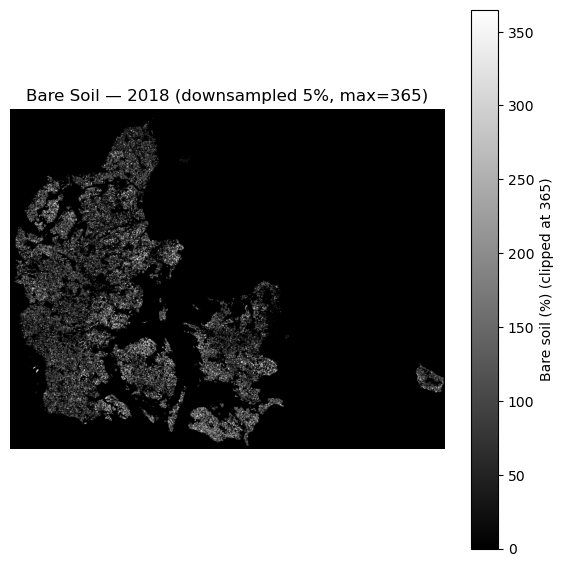

Loading: /home/georg/data/LEON_P5_BII/EO_data_prep/Bare/bare_before_dnk_2019_clip.tif


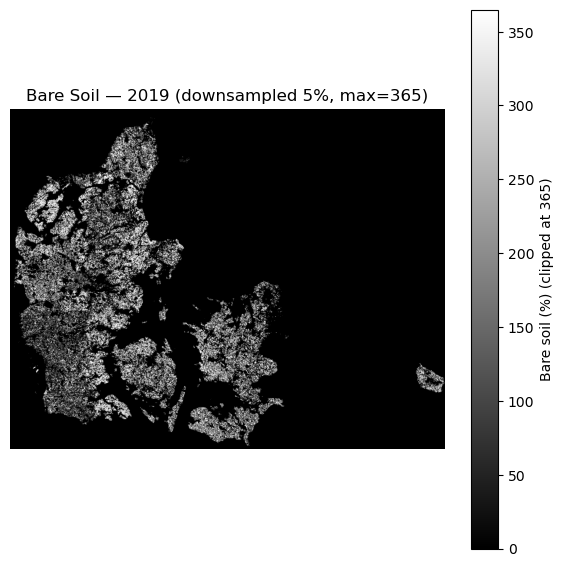

Loading: /home/georg/data/LEON_P5_BII/EO_data_prep/Bare/bare_before_dnk_2020_clip.tif


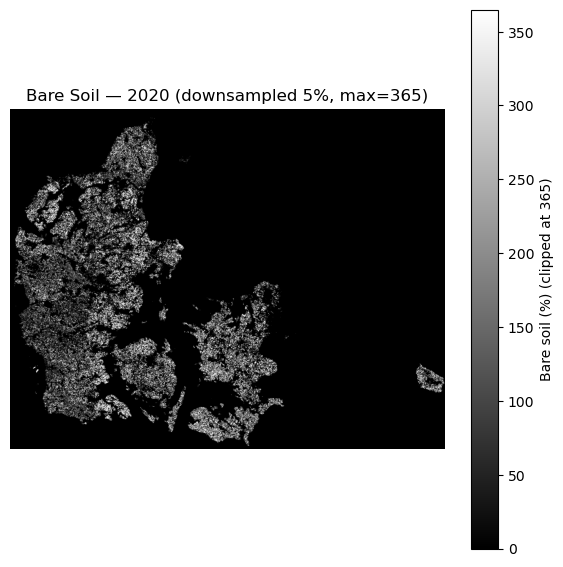

Loading: /home/georg/data/LEON_P5_BII/EO_data_prep/Bare/bare_before_dnk_2021_clip.tif


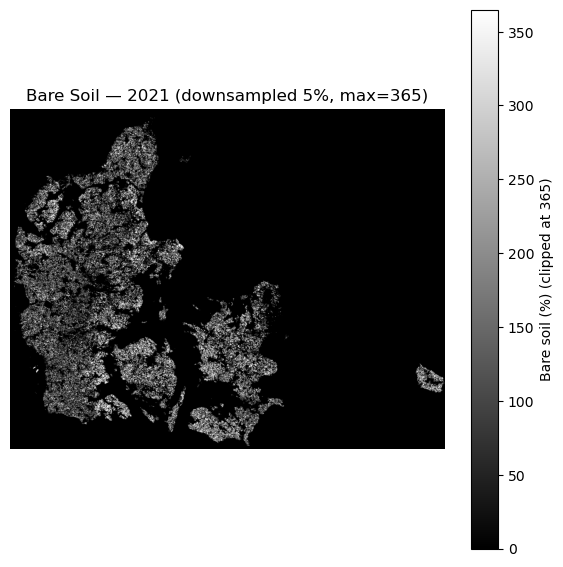

Loading: /home/georg/data/LEON_P5_BII/EO_data_prep/Bare/bare_before_dnk_2022_clip.tif


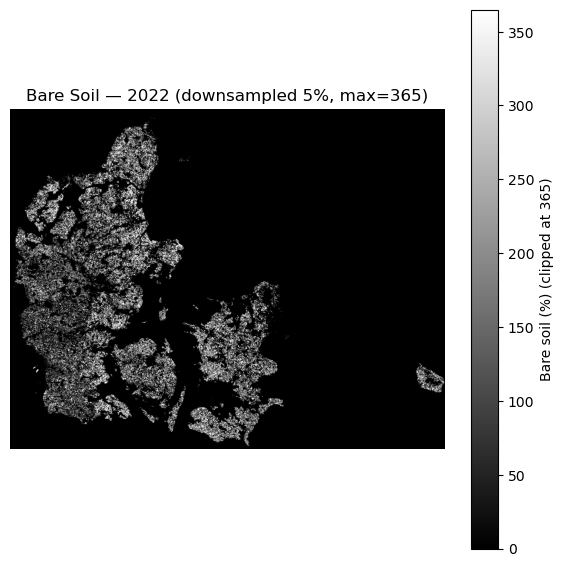

Loading: /home/georg/data/LEON_P5_BII/EO_data_prep/Bare/bare_before_dnk_2023_clip.tif


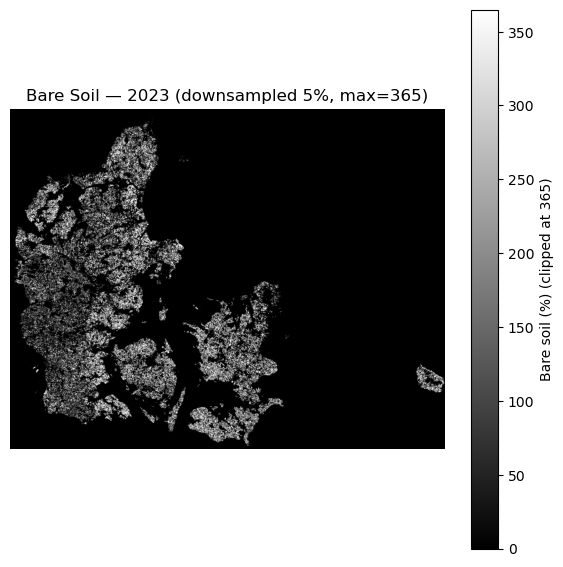

In [6]:
import rasterio
import matplotlib.pyplot as plt
import numpy as np
import os

base_path = "/home/georg/data/LEON_P5_BII/EO_data_prep/Bare"
scale = 0.05  # keep your resolution scaling

for year in range(2018, 2024):  # 2018–2023
    raster_path = os.path.join(
        base_path,
        f"bare_before_dnk_{year}_clip.tif"
    )

    print(f"Loading: {raster_path}")

    with rasterio.open(raster_path) as src:
        img = src.read(
            1,
            out_shape=(
                int(src.height * scale),
                int(src.width * scale)
            )
        )

    # ✅ Limit values so maximum is 365
    img = np.minimum(img, 365)

    plt.figure(figsize=(7, 7))
    plt.imshow(img, cmap="gray", vmin=0, vmax=365)
    plt.colorbar(label="Bare soil (%) (clipped at 365)")
    plt.title(f"Bare Soil — {year} (downsampled 5%, max=365)")
    plt.axis("off")
    plt.show()


### Grassland GPW

In [16]:
import subprocess
import tempfile
from pathlib import Path
import geopandas as gpd

# -----------------------------------------------------
# CONFIG
# -----------------------------------------------------
base_path = Path("/home/georg/data/LEON_P5_BII")

country = "nld"                                # "dnk" or "nld"
dataset  = "grassland_gpw"
folder   = "Grassland_GPW"

years = [2018, 2019, 2020, 2021, 2022, 2023]

# Load AOI (already in EPSG:3035)
aoi = gpd.read_file(base_path / "Country_Boundaries" / f"gadm41_{country}_adm_0_3035.gpkg")
target_crs = "EPSG:3035"

# -----------------------------------------------------
# PROCESSING LOOP
# -----------------------------------------------------
for year in years:

    tif_path = base_path / "EO_data_raw" / folder / f"{dataset}_{country}_{year}.tif"
    output_path = base_path / "EO_data_prep" / folder / f"{dataset}_{country}_{year}_clip.tif"
    output_path.parent.mkdir(parents=True, exist_ok=True)

    if not tif_path.exists():
        print(f"❌ Missing input raster: {tif_path}")
        continue

    print(f"\n=== Processing {country}, {year} ===")

    # Save AOI temporarily for GDAL
    with tempfile.TemporaryDirectory() as tmpdir:
        tmp_gpkg = Path(tmpdir) / "aoi.gpkg"
        aoi.to_file(tmp_gpkg, driver="GPKG")

        # GDAL warp
        cmd = [
            "gdalwarp",
            "-cutline", str(tmp_gpkg),
            "-crop_to_cutline",
            "-wo", "CUTLINE_ALL_TOUCHED=TRUE",
            "-t_srs", target_crs,      # reproject to 3035
            "-r", "nearest",           # grassland is categorical-ish
            "-tr", "30", "30",       # output resolution
            "-co", "COMPRESS=LZW",
            "-co", "TILED=YES",
            "-multi",
            "-wo", "NUM_THREADS=ALL_CPUS",
            str(tif_path),
            str(output_path)
        ]

        subprocess.run(cmd, check=True)

    print(f"✔ Saved: {output_path}")

print("\n🎉 All years done!")


=== Processing nld, 2018 ===
Creating output file that is 9211P x 10439L.
Processing /home/georg/data/LEON_P5_BII/EO_data_raw/Grassland_GPW/grassland_gpw_nld_2018.tif [1/1] : 0Using internal nodata values (e.g. 255) for image /home/georg/data/LEON_P5_BII/EO_data_raw/Grassland_GPW/grassland_gpw_nld_2018.tif.
Copying nodata values from source /home/georg/data/LEON_P5_BII/EO_data_raw/Grassland_GPW/grassland_gpw_nld_2018.tif to destination /home/georg/data/LEON_P5_BII/EO_data_prep/Grassland_GPW/grassland_gpw_nld_2018_clip.tif.
...10...20...30...40...50...60...70...80...90..✔ Saved: /home/georg/data/LEON_P5_BII/EO_data_prep/Grassland_GPW/grassland_gpw_nld_2018_clip.tif

=== Processing nld, 2019 ===
Creating output file that is 9211P x 10439L.
Processing /home/georg/data/LEON_P5_BII/EO_data_raw/Grassland_GPW/grassland_gpw_nld_2019.tif [1/1] : 0Using internal nodata values (e.g. 255) for image /home/georg/data/LEON_P5_BII/EO_data_raw/Grassland_GPW/grassland_gpw_nld_2019.tif.
Copying nodata v

### Lifestock GPW


In [18]:
# Batch processing for multiple datasets and years with GDAL warp and rasterio bilinear resampling + rounding to UInt16

from pathlib import Path
import subprocess
import tempfile
import geopandas as gpd
import rasterio
import numpy as np

base_path = Path("/home/georg/data/LEON_P5_BII")

country = "nld"
folder  = "Lifestock_GPW"

datasets = [
    "gpw_cattle.headcount.faostat_rf_m_1km_s",
    "gpw_goat.headcount.faostat_rf_m_1km_s",
    "gpw_horse.headcount.faostat_rf_m_1km_s",
    "gpw_sheep.headcount.faostat_rf_m_1km_s",
]

years = [2018, 2019, 2020, 2021, 2022, 2023]

aoi = gpd.read_file(base_path / "Country_Boundaries" / f"gadm41_{country}_adm_0_3035.gpkg")

for dataset in datasets:
    for year in years:

        raster_dir = base_path / "EO_data_raw" / folder
        matches = list(raster_dir.glob(f"{dataset}_*{year}*.tif"))
        if not matches:
            print(f"❌ No raster found for {dataset}, {year}")
            continue

        tif_path = matches[0]
        print(f"Processing: {tif_path.name}")

        float_tmp = base_path / "EO_data_prep" / folder / f"{dataset}_{country}_{year}_float.tif"
        out_final = base_path / "EO_data_prep" / folder / f"{dataset}_{country}_{year}_clip.tif"
        out_final.parent.mkdir(parents=True, exist_ok=True)

        with tempfile.TemporaryDirectory() as tmpdir:
            tmp_gpkg = Path(tmpdir) / "aoi.gpkg"
            aoi.to_file(tmp_gpkg, driver="GPKG")

            # STEP 1 — warp to Float32
            subprocess.run([
                "gdalwarp",
                "-cutline", str(tmp_gpkg),
                "-crop_to_cutline",
                "-wo", "CUTLINE_ALL_TOUCHED=TRUE",
                "-t_srs", "EPSG:3035",
                "-tr", "1000", "1000",
                "-r", "bilinear",
                "-ot", "Float32",
                "-dstnodata", "nan",
                "-co", "COMPRESS=LZW",
                "-co", "TILED=YES",
                str(tif_path),
                str(float_tmp)
            ], check=True)

        # STEP 2 — round → UInt16
        with rasterio.open(float_tmp) as src:
            arr = src.read(1)
            meta = src.meta.copy()

        # round & clamp safe range
        arr_rounded = np.rint(arr)                    # proper rounding
        arr_uint16  = np.where(np.isnan(arr_rounded), 65535, arr_rounded).astype("uint16")

        meta.update(
            dtype="uint16",
            nodata=65535
        )

        with rasterio.open(out_final, "w", **meta) as dst:
            dst.write(arr_uint16, 1)

        float_tmp.unlink()   # remove intermediate file

        print(f"✔ Saved final UInt16 raster: {out_final}")

print("\n🎉 All livestock layers processed successfully!")

Processing: gpw_cattle.headcount.faostat_rf_m_1km_s_20180101_20181231_go_esri.54052_v1 (1).tif
Creating output file that is 277P x 314L.
Processing /home/georg/data/LEON_P5_BII/EO_data_raw/Lifestock_GPW/gpw_cattle.headcount.faostat_rf_m_1km_s_20180101_20181231_go_esri.54052_v1 (1).tif [1/1] : 0Using internal nodata values (e.g. -32000) for image /home/georg/data/LEON_P5_BII/EO_data_raw/Lifestock_GPW/gpw_cattle.headcount.faostat_rf_m_1km_s_20180101_20181231_go_esri.54052_v1 (1).tif.
...10...20...30...40...50...60...70...80...90...100 - done.
✔ Saved final UInt16 raster: /home/georg/data/LEON_P5_BII/EO_data_prep/Lifestock_GPW/gpw_cattle.headcount.faostat_rf_m_1km_s_nld_2018_clip.tif
Processing: gpw_cattle.headcount.faostat_rf_m_1km_s_20190101_20191231_go_esri.54052_v1 (2).tif
Creating output file that is 277P x 314L.
Processing /home/georg/data/LEON_P5_BII/EO_data_raw/Lifestock_GPW/gpw_cattle.headcount.faostat_rf_m_1km_s_20190101_20191231_go_esri.54052_v1 (2).tif [1/1] : 0Using internal 

### For MODIS

In [ ]:
# Multiprocess clipping with GDAL

# --- Config ---
aoi = dnk  # Already loaded GeoDataFrame
country = "dnk"
year = 2021
dataset = "NPP"
folder = "Modis_NPP"

# Input raster
tif_path = base_path / "EO_data_prep" / folder / f"{dataset}_{country}_{year}.tif"
output_path = base_path / "EO_data_prep" / folder / f"{dataset}_{country}_{year}_clip.tif"

# Check input file exists
if not tif_path.exists():
    raise FileNotFoundError(f"Input raster not found: {tif_path}")

# --- Ensure AOI is in EPSG:3035 ---
target_crs = "EPSG:3035"
if aoi.crs != target_crs:
    print(f"Reprojecting AOI from {aoi.crs} to {target_crs}")
    aoi = aoi.to_crs(target_crs)
else:
    print(f"AOI already in {target_crs}")

# --- Save AOI to temporary GPKG for GDAL ---
with tempfile.TemporaryDirectory() as tmpdir:
    tmp_gpkg = Path(tmpdir) / "aoi.gpkg"
    aoi.to_file(tmp_gpkg, driver="GPKG")

    # --- GDAL command with reprojection ---
    cmd = [
        "gdalwarp",
        "-cutline", str(tmp_gpkg),
        "-crop_to_cutline",
        "-wo", "CUTLINE_ALL_TOUCHED=TRUE",          #  Include pixels that touch boundary
        "-t_srs", target_crs,
        "-tr", "300", "300",
        "-r", "bilinear",                #  Bilinear for continuous data
        "-of", "GTiff",
        "-co", "COMPRESS=LZW",
        "-co", "TILED=YES",
        "-multi",
        "-wo", "NUM_THREADS=ALL_CPUS",
        str(tif_path),
        str(output_path)
    ]

    print(f"Clipping and reprojecting {tif_path.name}...")
    subprocess.run(cmd, check=True)

print(f"✅ Clipped raster saved to: {output_path}")

# --- Verify output CRS ---
with rasterio.open(output_path) as src:
    print(f"Output CRS: {src.crs}")
    print(f"Output shape: {src.shape}")
    print(f"Output bounds: {src.bounds}")
    print(f"Output resolution: {src.res}")

### WorldClim Temp average + Reproject + Clip

In [ ]:
# Prepare WorldClim data. Calc mean annual temperature average from monthly rasters.

# --- Config --- #
aoi = nld  
country = "nld"
months = range(1, 13)  # 1-12
dataset = "wc2.1_2.5m_tavg"
folder = "Temp_avg"

input_dir = Path(f"/home/georg/data/LEON_P5_BII/EO_data_raw/{folder}")
output_path = Path(f"/home/georg/data/LEON_P5_BII/EO_data_prep/{folder}/{dataset}_{country}_mean_annual.tif")
output_path.parent.mkdir(parents=True, exist_ok=True)

# --- Process --- #
# Load all monthly rasters
monthly_rasters = []
for month in months:
    tif_path = input_dir / f"{dataset}_{month:02d}.tif"
    raster = rxr.open_rasterio(tif_path, masked=True)
    monthly_rasters.append(raster)

# Calculate mean annual temperature
mean_temp = xr.concat(monthly_rasters, dim='month').mean(dim='month')

# Reproject to EPSG:3035
mean_temp_reprojected = mean_temp.rio.reproject("EPSG:3035")

# Clip to country boundary
mean_temp_clipped = mean_temp_reprojected.rio.clip(aoi.geometry, aoi.crs, all_touched=True)

# Save
mean_temp_clipped.rio.to_raster(output_path, compress='lzw')

print(f"Saved: {output_path}")